#Random Forest Regression

É um algoritmo de ensemble (combinação de muitos modelos). Ensemble pode ocorrer de duas formas:

1. Bagging– Cria um subconjunto de treinamento diferente dos dados de treinamento. Encontra modelos diferentes. A resposta do target final é baseada na votação por maioria. Por exemplo, Random Forest.

2. Boosting – Combina modelos fracos e modelos fortes, criando modelos sequenciais de modo que o modelo final tenha a maior precisão. A cada nova iteração do modelo, os pesos dos dados mal classificados no modelo anterior aumentam. Por exemplo, ADA BOOST, XG BOOST

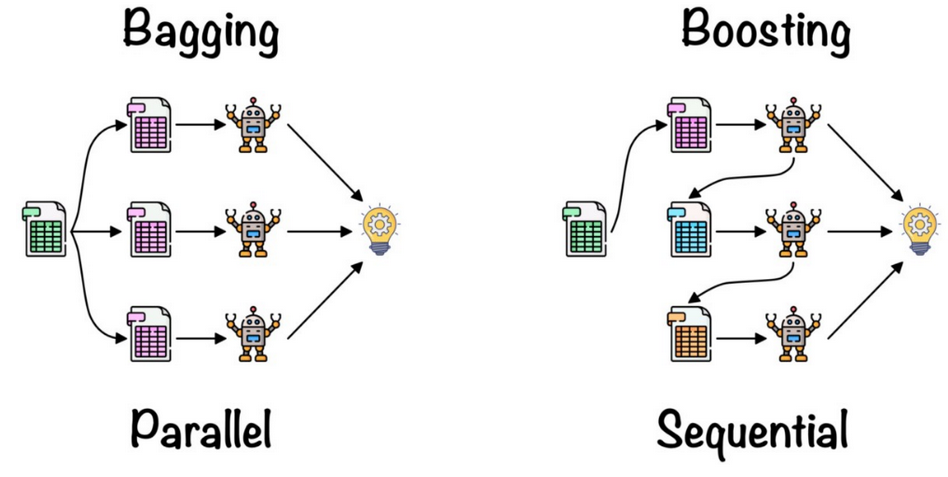

https://www.analyticsvidhya.com/blog/2021/06/understanding-random-forest/

Cada árvore utiliza features diferentes e em espaços de treinamento diferentes, gerando respostas diferentes.

A resposta final da Random Forest é a média de todos os resultados de regressão de cada uma das árvores.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#import seaborn as sns

from sklearn import tree

#from sklearn.impute import SimpleImputer
#from sklearn.compose import ColumnTransformer
#from sklearn.preprocessing import OneHotEncoder
#from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#from sklearn.linear_model import LinearRegression
#from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

#from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error


In [2]:
path = 'https://raw.githubusercontent.com/OrlandoIFPR/ml2/refs/heads/main/Dataframes/'

In [3]:
dataset = pd.read_csv(path+ 'melb_data.csv')

dataset.head()

,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,5,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [4]:
dataset = dataset.dropna(axis=0) #retira as linhas com NaN
features = ['Rooms', 'Bathroom', 'Landsize', 'Distance', 'BuildingArea', 'Car', 'YearBuilt','Postcode']

X = dataset[features]
y = dataset.Price

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

In [5]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(max_depth= 9, n_estimators = 50, random_state = 0)
# n_estimators - The number of trees in the forest.
regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=9, n_estimators=50, random_state=0)

In [6]:
y_pred = regressor.predict(X_test)
mae=mean_absolute_error(y_test, y_pred)
mae

187386.92118371718

##Cross Validation

Uma técnica para avaliar com uma maior confiabilidade a performance de um modelo de aprendizado de máquina é a validação cruzada. Ela divide o conjunto de
dados em N partes e faz N treinamentos, onde N é definido pelo usuário. Para cada treinamento uma das partes é utilizada como teste e todas as outras são utilizadas para treinamento.

No final do processo todos os dados terão sido utilizados como treino e teste, como mostra a Figura abaixo para um N = 4. O resultado dessa técnica é a média de todos os treinamentos para a métrica de avaliação escolhida.

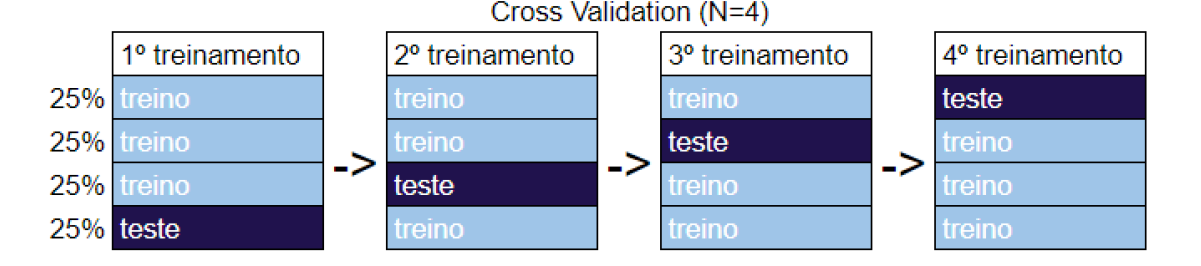

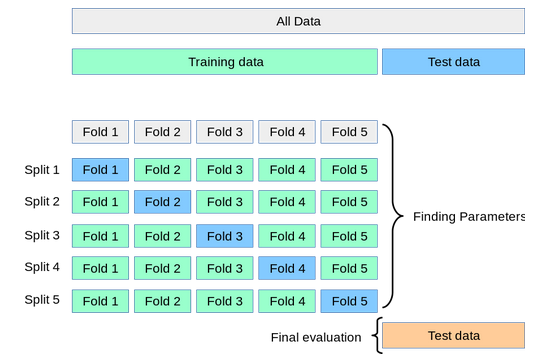

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
mae_cv = cross_val_score(regressor, X_train, y_train, scoring="neg_mean_absolute_error", cv=6)
#cv parametro para mudar dos 5 folds trad
-mae_cv.mean()

181532.08059502975

In [ ]:
mae_cv

array([-178238.07222169, -196339.68277647, -172869.52084261,
       -166314.35562256, -198262.72120777, -177168.13089908])

Documentação do valores para scoring: https://scikit-learn.org/stable/modules/model_evaluation.html

In [ ]:
-mae_cv.mean()/y.mean()

0.1726684574229731

##Hyperparameter Tuning

Os hiperparâmetros são argumentos de configuração do modelo especificados pelo desenvolvedor para orientar o processo de aprendizado para um conjunto de dados específico.

Os modelos de aprendizado de máquina também possuem parâmetros, que são os coeficientes internos definidos pelo treinamento ou pela otimização do modelo em um conjunto de dados de treinamento.

Os parâmetros são diferentes dos hiperparâmetros. Os parâmetros são aprendidos automaticamente; os hiperparâmetros são definidos manualmente para ajudar a orientar o processo de aprendizado.

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
#Não vou rodar, pois demora bastante tempo
params = {
'n_estimators':range(45,52),
'max_depth': range(8,11)
}
grid1 = GridSearchCV(regressor ,params, scoring='neg_mean_absolute_error', verbose=2)
grid1.fit(X_train,y_train)
print(grid1.best_params_, -grid1.best_score_)
rf_best = grid1.best_estimator_

Fitting 5 folds for each of 21 candidates, totalling 105 fits
[CV] END .......................max_depth=8, n_estimators=45; total time=   0.4s
[CV] END .......................max_depth=8, n_estimators=45; total time=   0.4s
[CV] END .......................max_depth=8, n_estimators=45; total time=   0.4s
[CV] END .......................max_depth=8, n_estimators=45; total time=   0.4s
[CV] END .......................max_depth=8, n_estimators=45; total time=   0.4s
[CV] END .......................max_depth=8, n_estimators=46; total time=   0.4s
[CV] END .......................max_depth=8, n_estimators=46; total time=   0.4s
[CV] END .......................max_depth=8, n_estimators=46; total time=   0.4s
[CV] END .......................max_depth=8, n_estimators=46; total time=   0.4s
[CV] END .......................max_depth=8, n_estimators=46; total time=   0.4s
[CV] END .......................max_depth=8, n_estimators=47; total time=   0.4s
[CV] END .......................max_depth=8, n_

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


{'max_depth': 10, 'n_estimators': 51} 181578.0548735296


In [ ]:
-grid1.best_score_/y_train.mean()

0.17134373467415362

In [ ]:
y_pred = rf_best.predict(X_test)
mae_rf_best=mean_absolute_error(y_test, y_pred)
print(mae_rf_best)
print(mae_rf_best/y_test.mean())


185532.45286849115
0.1706804733767205


In [ ]:
rf_best.feature_importances_

array([0.0189694 , 0.02334029, 0.07020052, 0.16222394, 0.43492266,
       0.01079069, 0.14388507, 0.13566744])

In [ ]:
imp_df = pd.DataFrame({
    "Varname": X_train.columns,
    "Imp": rf_best.feature_importances_
})

In [ ]:
imp_df.sort_values(by="Imp", ascending=False)

,Varname,Imp
4,BuildingArea,0.434923
3,Distance,0.162224
6,YearBuilt,0.143885
7,Postcode,0.135667
2,Landsize,0.070201
1,Bathroom,0.023340
0,Rooms,0.018969
5,Car,0.010791


Neste ponto, podemos selecionar árvores específicas e fazer a visualização, como feito no caso simples de Árvore de Decisão. A Random Forest vira um array de Árvores de Decisão.

##Passo a passo para avaliação de um modelo

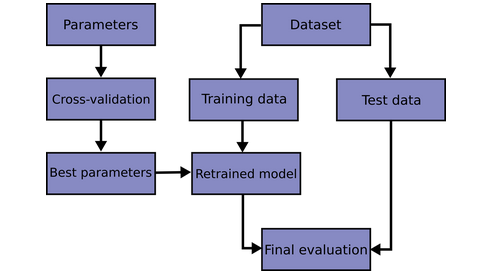